# KPZ in d=1 — a per-leg gradient vertex

**Showcases:** a **derivative** vertex. KPZ's nonlinearity $(\lambda/2)(\partial_x h)^2$ attaches a momentum factor to each leg of the vertex, which the pipeline handles with a per-leg gradient form-factor (not the plain polynomial path of Allen–Cahn).

$$\partial_t h = D\,\partial_x^2 h + \tfrac{\lambda}{2}(\partial_x h)^2 + \eta.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — domain, fields, parameters, kernels, and the governing equation.

In [2]:
THEORY = 'kpz_1d'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)

────────────────────────────────────────────────────────────────────────
  1D KPZ (per-leg gradient vertex)
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=1 · boundary=infinite · initial=stationary
Fields         : h (x∈ℝ^1) — interface height
Response fields: ht
Parameters     :
    mu = 1.0  (positive)
    D = 1.0  (positive)
    lam = 0.3  (real)
    T = 1.0  (positive)
Mean-field saddle (solved by the pipeline): hstar
Suggested run  : k=2, max_ell=1

1D KPZ equation (with a confining mass) — a *per-leg* gradient vertex test
theory for the spatial v2 operator IR.

    ∂_t h  =  -μ h  +  D ∇²h  +  (λ/2) (∂_x h)²  +  η ,
    ⟨η(x,t) η(x',t')⟩  =  2T δ(x-x') δ(t-t').

The ``-μh`` damping (a confining/Edwards-Wilkinson mass) makes the propagator
massive and IR-safe and isolates the homogeneous saddle ``h*=0`` (the gradient
forcing ``(∂_x h)²`` vanishes there).  Pure KPZ is the ``μ→0`` limit.

The defining feature vs Burgers: the

"────────────────────────────────────────────────────────────────────────\n  1D KPZ (per-leg gradient vertex)\n────────────────────────────────────────────────────────────────────────\nDomain         : spatial PDE · d=1 · boundary=infinite · initial=stationary\nFields         : h (x∈ℝ^1) — interface height\nResponse fields: ht\nParameters     :\n    mu = 1.0  (positive)\n    D = 1.0  (positive)\n    lam = 0.3  (real)\n    T = 1.0  (positive)\nMean-field saddle (solved by the pipeline): hstar\nSuggested run  : k=2, max_ell=1\n\n1D KPZ equation (with a confining mass) — a *per-leg* gradient vertex test\ntheory for the spatial v2 operator IR.\n\n    ∂_t h  =  -μ h  +  D ∇²h  +  (λ/2) (∂_x h)²  +  η ,\n    ⟨η(x,t) η(x',t')⟩  =  2T δ(x-x') δ(t-t').\n\nThe ``-μh`` damping (a confining/Edwards-Wilkinson mass) makes the propagator\nmassive and IR-safe and isolates the homogeneous saddle ``h*=0`` (the gradient\nforcing ``(∂_x h)²`` vanishes there).  Pure KPZ is the ``μ→0`` limit.\n\nThe definin

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). The plot is the **theory only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=1,
    external_fields=[('dh', 1), ('dh', 1)],
    spatial_grid=(0.0, 10.0, 30),
    tau_max=0.0,
)

theory : '1D KPZ (per-leg gradient vertex)'
k      : 2    max_ell : 1
fields : ['dh']   spatial_dim : 1
diagrams (live): 3


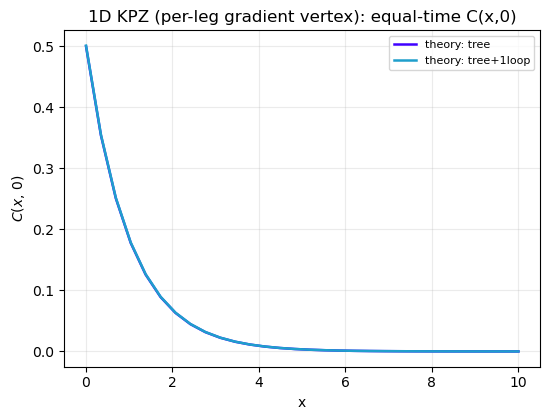

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct numerical integration of the SPDE — written from scratch, with no reference to the diagrammatics. Overlaying it on the pipeline curve is the validation.

theory C(0) = 0.5011   sim C(0) = 0.5000   (sim mean = 0.406)


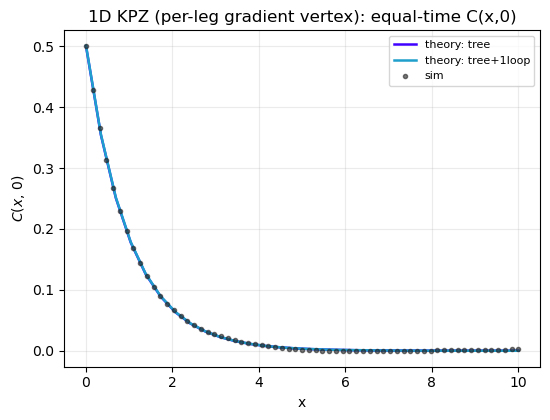

In [5]:
# Independent SPDE simulation (direct ETD1 integration) — NOT the
# pipeline.  Same physical parameters as the theory (read from the model).
from models.spatial_field_1d_sim import simulate, equal_time_correlator
fp = dd.fundamental_from_model(model)
snaps, x_grid, meta = simulate(L=20.0, N=128, mu=fp['mu'], D=fp['D'], T=fp['T'],
                               lam_kpz=fp['lam'],
                               n_steps=150000, burn_in=30000, record_every=20, seed=1)
mean = float(np.mean(snaps))      # ⟨φ⟩: ≈0 if symmetric, the excess velocity for KPZ
Cx = equal_time_correlator(snaps) - mean**2   # CONNECTED (the pipeline gives connected)
half = len(x_grid) // 2 + 1
sim = {'x': x_grid[:half], 'C': Cx[:half]}
mid = res['C_tau_x'].shape[0] // 2
print('theory C(0) = %.4f   sim C(0) = %.4f   (sim mean = %.3f)'
      % (np.real(res['C_tau_x'])[mid][0], sim['C'][0], mean))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

### The genuine nonlinear signature: excess velocity

In **d=1**, KPZ shares the linear (Edwards–Wilkinson) *stationary* measure, so the equal-time `C(x)` above is **λ-independent** — the vertex leaves the static variance untouched (the pipeline and sim agree on the EW value). Where the per-leg gradient vertex *does* show up is the **excess velocity** $\langle\dot h\rangle = (\lambda/2\mu)\,\langle(\partial_x h)^2\rangle$ — a drift absent in the linear theory. The sim's mean height-rate matches the tree-level lattice prediction:

In [6]:
# Tree-level lattice prediction for the KPZ excess velocity vs the sim drift.
dx, Nsim, Lsim = meta['dx'], meta['N'], meta['L']
ks   = 2.0 * np.pi * np.fft.fftfreq(Nsim, d=dx)
disp = fp['mu'] + (2.0 * fp['D'] / dx**2) * (1.0 - np.cos(ks * dx))
ddh2 = (fp['T'] / Lsim) * np.sum((np.sin(ks * dx) / dx) ** 2 / disp)
exc_theory = (fp['lam'] / (2.0 * fp['mu'])) * ddh2
print('KPZ excess velocity  ⟨h⟩ = (λ/2μ)⟨(∂ₓh)²⟩')
print('   sim    = %.4f' % mean)
print('   theory = %.4f   (ratio %.3f)' % (exc_theory, mean / exc_theory))

KPZ excess velocity  ⟨h⟩ = (λ/2μ)⟨(∂ₓh)²⟩
   sim    = 0.4065
   theory = 0.4106   (ratio 0.990)


## Summary

KPZ is the **per-leg gradient vertex**: the same diagram machinery as Allen–Cahn, but with a `∂ₓ → ik` form-factor on each leg. In d=1 the static `C(x)` is λ-independent (EW stationary measure) — pipeline and sim agree — and the nonlinearity reveals itself in the excess velocity, which matches the tree-level lattice prediction to ~1%.